In [1]:
import pybedtools
from pybedtools import BedTool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

load specific files

In [2]:
genome = 'GRCh38_EBV.chrom.sizes.tsv'

hot_loci_name = 'hot_regions.clean.bed'
h3k4me3_name = 'K562_H3K4me3.bed'
h3k27ac_name = 'K562_H3K27ac.bed'
h3k27me3_name = 'K562_H3k27me3.bed'
h3k9me3_name = 'K562_H3K9me3.bed'

hot = BedTool(hot_loci_name).sort(g=genome)
marks = {
    'H3K4me3': BedTool(h3k4me3_name).sort(g=genome),
    'H3K27ac': BedTool(h3k27ac_name).sort(g=genome),
    'H3K27me3': BedTool(h3k27me3_name).sort(g=genome),
    'H3K9me3': BedTool(h3k9me3_name).sort(g=genome),
}

n_hot = hot.count()

print(n_hot, 'hot regions')
for name, bt in marks.items():
    print(bt.count(), name, 'peaks')

5990 hot regions
21445 H3K4me3 peaks
52334 H3K27ac peaks
163784 H3K27me3 peaks
5584 H3K9me3 peaks


enrichment of each mark at hot loci vs rest -- odds ratio forest plot. uses a Haldane-Anscombe continuity correction (+0.5 to all cells) only when a cell is zero, so a mark with no overlap at all doesn't produce an OR of exactly 0 or infinity and break the plot

In [5]:
def or_ci(a, b, c, d, alpha=0.05):
    if min(a, b, c, d) == 0:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    odds = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    z = 1.96
    lo = np.exp(np.log(odds) - z * se)
    hi = np.exp(np.log(odds) + z * se)
    return odds, lo, hi

forest_rows = []
for mark_name, mark_bt in marks.items():
    res = mark_bt.fisher(hot, g=genome)
    t = res.table
    a, b = t['in -a']['in -b'], t['in -a']['not in -b']
    c, d = t['not in -a']['in -b'], t['not in -a']['not in -b']
    odds, lo, hi = or_ci(a, b, c, d)
    forest_rows.append({'mark': mark_name, 'or': odds, 'ci_low': lo, 'ci_high': hi, 'p': res.two_tail})

forest_df = pd.DataFrame(forest_rows)
forest_df

,mark,or,ci_low,ci_high,p
0,H3K4me3,5.867875,5.497898,6.262750e+00,0.000000e+00
1,H3K27ac,385015.879689,24079.419999,6.156179e+06,0.000000e+00
2,H3K27me3,0.137927,0.123339,1.542394e-01,0.000000e+00
3,H3K9me3,5.823212,5.153414,6.580066e+00,3.848300e-113


keep the existing bivalent (H3K4me3 ∩ H3K27me3) vs hot comparison already established, and fold it into the same forest plot

In [6]:
both = marks['H3K4me3'].intersect(marks['H3K27me3']).sort(g=genome).merge()
n_both = both.count()
print(n_both)

both_in_hot = both.intersect(hot, u=True)
both_not_in_hot = both.intersect(hot, v=True)

n_hot_overlap = both_in_hot.count()
percent_hot = 100 * n_hot_overlap / n_both if n_both else 0

n_not_hot_overlap = both_not_in_hot.count()
percent_not_hot = 100 * n_not_hot_overlap / n_both if n_both else 0

print('of all regions which have both an active (H3K4me3) and inactive (H3K27me3) mark')
print(f'hot region    : {n_hot_overlap:5d} {percent_hot:.2f}%')
print(f'not hot region: {n_not_hot_overlap:5d} {percent_not_hot:.2f}%')

res_biv = both.fisher(hot, g=genome)
print(res_biv)

t = res_biv.table
a, b = t['in -a']['in -b'], t['in -a']['not in -b']
c, d = t['not in -a']['in -b'], t['not in -a']['not in -b']
odds, lo, hi = or_ci(a, b, c, d)
forest_df.loc[len(forest_df)] = {'mark': 'bivalent (H3K4me3∩H3K27me3)', 'or': odds,
                                   'ci_low': lo, 'ci_high': hi, 'p': res_biv.two_tail}
forest_df

3692
of all regions which have both an active (H3K4me3) and inactive (H3K27me3) mark
hot region    :     9 0.24%
not hot region:  3683 99.76%
# Number of query intervals: 3692
# Number of db intervals: 5990
# Number of overlaps: 9
# Number of possible intervals (estimated): 594407
# phyper(9 - 1, 3692, 594407 - 3692, 5990, lower.tail=F)
# Contingency Table Of Counts
#_________________________________________
#           |  in -b       | not in -b    |
#     in -a | 9            | 3683         |
# not in -a | 5981         | 584734       |
#_________________________________________
# p-values for fisher's exact test
left	right	two-tail	ratio
2.859e-08	1	5.3274e-08	0.239



,mark,or,ci_low,ci_high,p
0,H3K4me3,5.867875,5.497898,6.262750e+00,0.000000e+00
1,H3K27ac,385015.879689,24079.419999,6.156179e+06,0.000000e+00
2,H3K27me3,0.137927,0.123339,1.542394e-01,0.000000e+00
3,H3K9me3,5.823212,5.153414,6.580066e+00,3.848300e-113
4,bivalent (H3K4me3∩H3K27me3),0.238905,0.124144,4.597547e-01,5.327400e-08


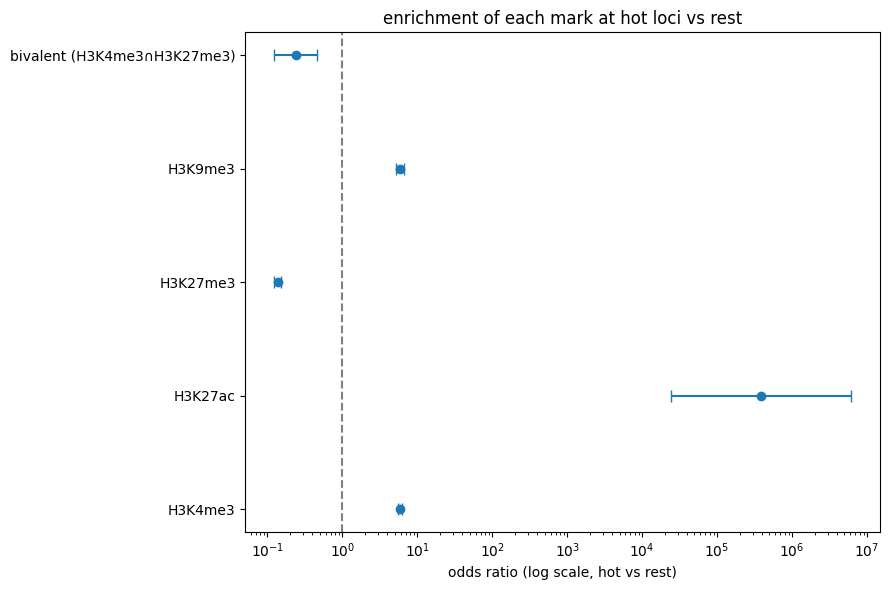

In [7]:
y_pos = np.arange(len(forest_df))

plt.figure(figsize=(9, 6))
plt.errorbar(forest_df['or'], y_pos,
             xerr=[forest_df['or'] - forest_df['ci_low'], forest_df['ci_high'] - forest_df['or']],
             fmt='o', capsize=4)
plt.yticks(y_pos, forest_df['mark'])
plt.axvline(1, color='grey', linestyle='--')
plt.xscale('log')
plt.xlabel('odds ratio (log scale, hot vs rest)')
plt.title('enrichment of each mark at hot loci vs rest')
plt.tight_layout()
plt.savefig('plot6_forest.png', dpi=300)
plt.show()

percentile-binned design: blacklist-filter the full occupancy set first, then bin by occupancy so the active-vs-repressive comparison isn't limited to just the top 1% hot loci

In [8]:
blacklist = BedTool('hg38-blacklist.v2.bed.gz').sort(g=genome)
df = pd.read_csv('merged_tf_counts.bed', sep='\t',
                 names=['chrom', 'start', 'end', 'tfs', 'n_tfs'])
df = df.reset_index().rename(columns={'index': 'locus_id'})

loci_bt = BedTool.from_dataframe(df[['chrom', 'start', 'end', 'locus_id']]).sort(g=genome)
tagged = loci_bt.intersect(blacklist, c=True)
tagged_df = tagged.to_dataframe(names=['chrom', 'start', 'end', 'locus_id', 'blacklist_count'])
df = df.merge(tagged_df[['locus_id', 'blacklist_count']], on='locus_id')

df_clean = df[df['blacklist_count'] == 0].copy()
print(f'{len(df)} loci before blacklist filter, {len(df_clean)} after')

597170 loci before blacklist filter, 594202 after


assign occupancy percentile bins

In [9]:
edges = (0, 50, 80, 90, 95, 99, 100)
quantiles = [e / 100 for e in edges]
bin_edges = df_clean['n_tfs'].quantile(quantiles).values
labels = [f'{edges[i]}-{edges[i+1]}' for i in range(len(edges) - 1)]

df_clean['occupancy_bin'] = pd.cut(df_clean['n_tfs'], bins=bin_edges, labels=labels,
                                     include_lowest=True, duplicates='drop')
df_clean['occupancy_bin'].value_counts().sort_index()

occupancy_bin
0-50      375483
50-80     112304
80-90      48007
90-95      28740
95-99      23752
99-100      5916
Name: count, dtype: int64

binary overlap (%) by occupancy bin, per mark -- the core non-circular comparison: are repressive marks enriched at high occupancy the same way active marks are, or not

In [10]:
clean_bt = BedTool.from_dataframe(
    df_clean[['chrom', 'start', 'end', 'occupancy_bin']].astype({'occupancy_bin': str})
).sort(g=genome)

overlap_rows = []
for mark_name, mark_bt in marks.items():
    hits = clean_bt.intersect(mark_bt, c=True)
    hits_df = hits.to_dataframe(names=['chrom', 'start', 'end', 'occupancy_bin', 'overlap_count'])
    hits_df['overlaps'] = hits_df['overlap_count'] > 0
    summary = hits_df.groupby('occupancy_bin', observed=True)['overlaps'].mean().mul(100)
    for b, pct in summary.items():
        overlap_rows.append({'mark': mark_name, 'occupancy_bin': b, 'pct_overlap': pct})

overlap_df = pd.DataFrame(overlap_rows)
overlap_df

,mark,occupancy_bin,pct_overlap
0,H3K4me3,0-50,1.798750
1,H3K4me3,50-80,2.223429
2,H3K4me3,80-90,2.810007
3,H3K4me3,90-95,3.535143
4,H3K4me3,95-99,6.824688
5,H3K4me3,99-100,14.435429
6,H3K27ac,0-50,0.559546
7,H3K27ac,50-80,1.530667
8,H3K27ac,80-90,4.972192
9,H3K27ac,90-95,17.226862


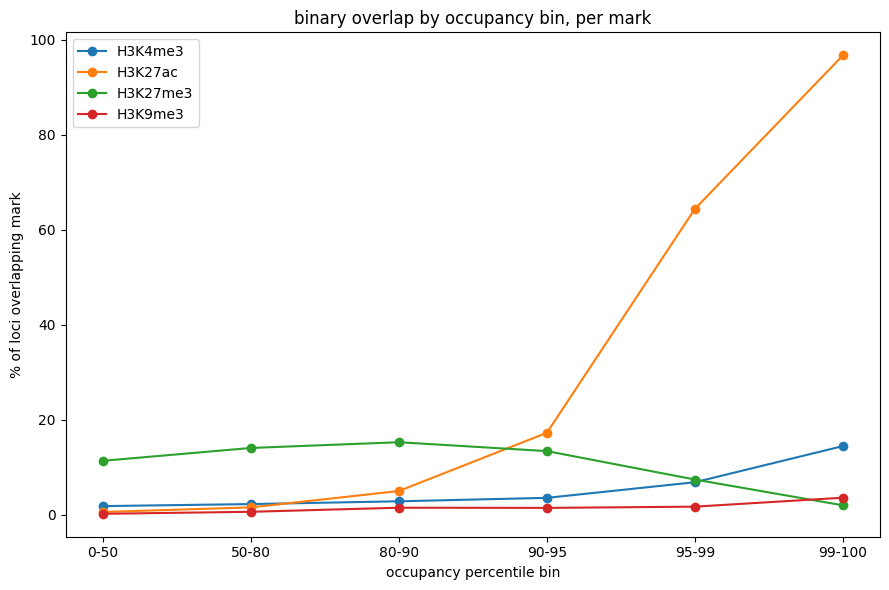

In [11]:
bin_order = list(df_clean['occupancy_bin'].cat.categories)

plt.figure(figsize=(9, 6))
for mark_name in marks:
    sub = overlap_df[overlap_df['mark'] == mark_name].set_index('occupancy_bin').reindex(bin_order)
    plt.plot(bin_order, sub['pct_overlap'], marker='o', label=mark_name)

plt.xlabel('occupancy percentile bin')
plt.ylabel('% of loci overlapping mark')
plt.title('binary overlap by occupancy bin, per mark')
plt.legend()
plt.tight_layout()
plt.savefig('plot5_overlap_by_bin.png', dpi=300)
plt.show()